# Variante LSTM — Juan Camilo Gallardo

Entrenamiento del `CharRNN(cell_type='lstm')` para generar nombres de dinosaurios.

Reutiliza el núcleo compartido en [src/](../src/): `dataset.py`, `model.py`, `train.py`, `sample.py`.

**Hiperparámetros**: `embed_dim=32`, `hidden_dim=128`, `num_layers=1` (+ variante con `num_layers=2, dropout=0.2`), `lr=1e-3`, `batch_size=64`, `patience=5`.

Ejecuta este notebook desde la **raíz del repo** para que los imports relativos funcionen.

In [1]:
import sys, os
from pathlib import Path

REPO_ROOT = Path.cwd()
while REPO_ROOT.name and not (REPO_ROOT / 'CLAUDE.md').exists():
    REPO_ROOT = REPO_ROOT.parent
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
print('cwd:', os.getcwd())

cwd: /home/ec2-user/SageMaker


In [2]:
import torch
import matplotlib.pyplot as plt
import math
from Parte_1_Generador_Caracteres.src.dataset import make_dataloaders, load_names
from Parte_1_Generador_Caracteres.src.model import CharRNN
from Parte_1_Generador_Caracteres.src.sample import load_model, generate_unique

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device: cpu


## 1. Datos

In [3]:
names = load_names('data/dinos.csv')
print(f'total nombres: {len(names)}')
print(f'longitud min/max: {min(map(len, names))}/{max(map(len, names))}')
print('ejemplos:', names[:5])

total nombres: 1536
longitud min/max: 3/26
ejemplos: ['aachenosaurus', 'aardonyx', 'abdallahsaurus', 'abelisaurus', 'abrictosaurus']


In [4]:
train_loader, val_loader, vocab, max_len = make_dataloaders('data/dinos.csv', batch_size=64)
print(f'vocab_size={len(vocab)}, max_len={max_len}')
print(f'train batches={len(train_loader)}, val batches={len(val_loader)}')

vocab_size=29, max_len=28
train batches=22, val batches=3


## 2. Entrenamiento — LSTM 1 capa

Configuración base: `num_layers=1`, sin dropout.

In [5]:
from argparse import Namespace
from Parte_1_Generador_Caracteres.src.train import train

args_1layer = Namespace(
    data='data/dinos.csv',
    cell='lstm',
    epochs=50,
    batch_size=64,
    embed=32,
    hidden=128,
    layers=1,
    lr=1e-3,
    patience=5,
    checkpoint='Parte_1_Generador_Caracteres/models/lstm_1layer_JuanCamiloGallardo.pt',
    run_tag='JuanCamiloGallardo_1layer',
)
history_1, best_val_1 = train(args_1layer)
print(f'\nbest val loss (1 capa): {best_val_1:.4f}  ppl={math.exp(best_val_1):.2f}')

[train] device=cpu, cell=lstm


/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/pydantic/_internal/_fields.py:132: UserWarning: Field "model_name" in PromptModelConfig has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(
2026/05/10 15:14:51 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/10 15:14:51 INFO mlflow.store.db.utils: Updating database tables
2026/05/10 15:14:53 INFO mlflow.tracking.fluent: Experiment with name 'dino-charrnn' does not exist. Creating a new experiment.


epoch 01 | train 3.1189 | val 2.6692
epoch 02 | train 2.5396 | val 2.3255
epoch 03 | train 2.2610 | val 2.0987
epoch 04 | train 2.0908 | val 1.9682
epoch 05 | train 1.9953 | val 1.8932
epoch 06 | train 1.9321 | val 1.8426
epoch 07 | train 1.8858 | val 1.7949
epoch 08 | train 1.8459 | val 1.7666
epoch 09 | train 1.8121 | val 1.7446
epoch 10 | train 1.7857 | val 1.7209
epoch 11 | train 1.7578 | val 1.6896
epoch 12 | train 1.7325 | val 1.6704
epoch 13 | train 1.7119 | val 1.6543
epoch 14 | train 1.6905 | val 1.6327
epoch 15 | train 1.6714 | val 1.6187
epoch 16 | train 1.6528 | val 1.6059
epoch 17 | train 1.6355 | val 1.5986
epoch 18 | train 1.6197 | val 1.5890
epoch 19 | train 1.6025 | val 1.5723
epoch 20 | train 1.5902 | val 1.5599
epoch 21 | train 1.5741 | val 1.5577
epoch 22 | train 1.5608 | val 1.5495
epoch 23 | train 1.5472 | val 1.5385
epoch 24 | train 1.5324 | val 1.5315
epoch 25 | train 1.5176 | val 1.5326
epoch 26 | train 1.5073 | val 1.5246
epoch 27 | train 1.4939 | val 1.5176
e

## 3. Entrenamiento — LSTM 2 capas + dropout 0.2

LSTM suele beneficiarse de más profundidad. Comparamos ambas configuraciones.

In [6]:
args_2layer = Namespace(
    data='data/dinos.csv',
    cell='lstm',
    epochs=50,
    batch_size=64,
    embed=32,
    hidden=128,
    layers=2,
    lr=1e-3,
    patience=5,
    checkpoint='Parte_1_Generador_Caracteres/models/lstm_2layer_JuanCamiloGallardo.pt',
    run_tag='JuanCamiloGallardo_2layer',
)
history_2, best_val_2 = train(args_2layer)
print(f'\nbest val loss (2 capas): {best_val_2:.4f}  ppl={math.exp(best_val_2):.2f}')

[train] device=cpu, cell=lstm
epoch 01 | train 3.0957 | val 2.7651
epoch 02 | train 2.6826 | val 2.5409
epoch 03 | train 2.4320 | val 2.2540
epoch 04 | train 2.2115 | val 2.0695
epoch 05 | train 2.0726 | val 1.9446
epoch 06 | train 1.9724 | val 1.8663
epoch 07 | train 1.9151 | val 1.8092
epoch 08 | train 1.8636 | val 1.7699
epoch 09 | train 1.8236 | val 1.7377
epoch 10 | train 1.7885 | val 1.7089
epoch 11 | train 1.7577 | val 1.6854
epoch 12 | train 1.7309 | val 1.6642
epoch 13 | train 1.7050 | val 1.6418
epoch 14 | train 1.6789 | val 1.6257
epoch 15 | train 1.6567 | val 1.6084
epoch 16 | train 1.6348 | val 1.6030
epoch 17 | train 1.6172 | val 1.5853
epoch 18 | train 1.5956 | val 1.5747
epoch 19 | train 1.5782 | val 1.5706
epoch 20 | train 1.5607 | val 1.5585
epoch 21 | train 1.5405 | val 1.5485
epoch 22 | train 1.5241 | val 1.5452
epoch 23 | train 1.5053 | val 1.5314
epoch 24 | train 1.4883 | val 1.5310
epoch 25 | train 1.4745 | val 1.5319
epoch 26 | train 1.4537 | val 1.5213
epoch 27

## 4. Comparación de configuraciones

In [7]:
print('Configuración        | Val Loss | Perplexity')
print('---------------------|----------|----------')
print(f'LSTM 1 capa          | {best_val_1:.4f}   | {math.exp(best_val_1):.2f}')
print(f'LSTM 2 capas dropout | {best_val_2:.4f}   | {math.exp(best_val_2):.2f}')

# Seleccionar la mejor configuración
if best_val_1 <= best_val_2:
    best_val = best_val_1
    best_args = args_1layer
    best_history = history_1
    print('\n→ Ganadora: LSTM 1 capa')
else:
    best_val = best_val_2
    best_args = args_2layer
    best_history = history_2
    print('\n→ Ganadora: LSTM 2 capas')

Configuración        | Val Loss | Perplexity
---------------------|----------|----------
LSTM 1 capa          | 1.4853   | 4.42
LSTM 2 capas dropout | 1.5074   | 4.52

→ Ganadora: LSTM 1 capa


## 5. Curvas de aprendizaje

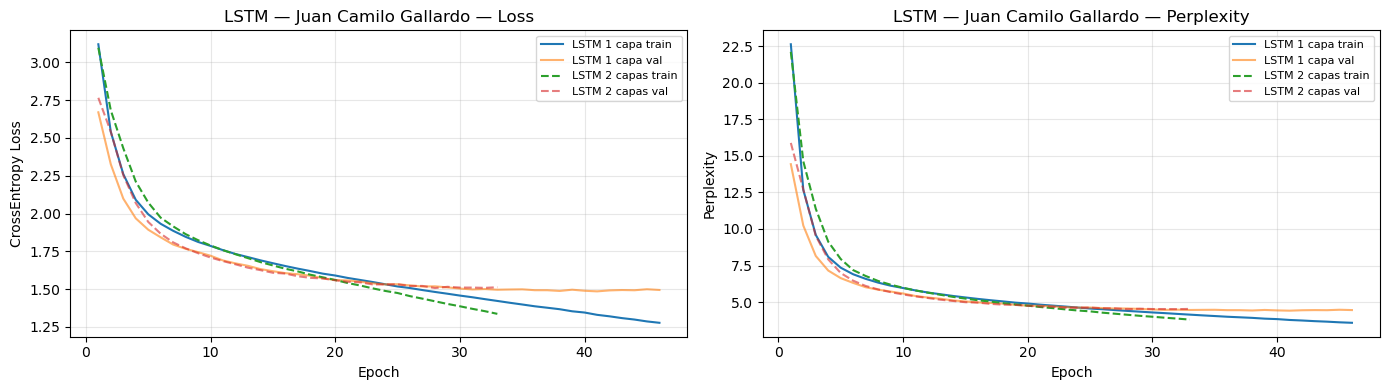

Guardado en reports/learning_curves_lstm.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for history, label, style in [
    (history_1, 'LSTM 1 capa', '-'),
    (history_2, 'LSTM 2 capas', '--'),
]:
    ep = list(range(1, len(history['train_loss']) + 1))
    axes[0].plot(ep, history['train_loss'], style, label=f'{label} train')
    axes[0].plot(ep, history['val_loss'],   style, alpha=0.6, label=f'{label} val')
    axes[1].plot(ep, [math.exp(l) for l in history['train_loss']], style, label=f'{label} train')
    axes[1].plot(ep, [math.exp(l) for l in history['val_loss']],   style, alpha=0.6, label=f'{label} val')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CrossEntropy Loss')
axes[0].set_title('LSTM — Juan Camilo Gallardo — Loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('LSTM — Juan Camilo Gallardo — Perplexity')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig('reports/learning_curves_lstm.png', dpi=120, bbox_inches='tight')
plt.show()
print('Guardado en reports/learning_curves_lstm.png')

## 6. Métricas finales

In [9]:
best_train = min(best_history['train_loss'])
print(f'Épocas entrenadas : {len(best_history["train_loss"])}')
print(f'Mejor train loss  : {best_train:.4f}  (ppl = {math.exp(best_train):.2f})')
print(f'Mejor val loss    : {best_val:.4f}  (ppl = {math.exp(best_val):.2f})')
print(f'Checkpoint        : {best_args.checkpoint}')

Épocas entrenadas : 46
Mejor train loss  : 1.2776  (ppl = 3.59)
Mejor val loss    : 1.4853  (ppl = 4.42)
Checkpoint        : Parte_1_Generador_Caracteres/models/lstm_1layer_JuanCamiloGallardo.pt


## 7. Muestreo — 5 nombres

In [10]:
model_lstm, vocab_lstm, max_len_lstm = load_model(best_args.checkpoint, device=device)
seen = set(load_names('data/dinos.csv'))

sample_names = generate_unique(
    model_lstm, vocab_lstm, max_len_lstm,
    n=5, temperature=1.0, top_k=None, top_p=0.9,
    seen=seen, device=device,
)
print('5 nombres generados por la LSTM (temperature=1.0, top_p=0.9):')
for name in sample_names:
    print(f'  → {name}')

5 nombres generados por la LSTM (temperature=1.0, top_p=0.9):
  → baronyanus
  → lanzhomesaurus
  → raphosaurus
  → ancenlosaurus
  → linganthomesaurus


## 8. Barrido de parámetros de muestreo

In [11]:
import itertools, csv

temperatures = [0.7, 1.0, 2.5, 4.0]
top_ks       = [None, 5, 10]
top_ps       = [None, 0.9, 0.95]

rows = []
for temp, tk, tp in itertools.product(temperatures, top_ks, top_ps):
    batch = generate_unique(
        model_lstm, vocab_lstm, max_len_lstm,
        n=3, temperature=temp, top_k=tk, top_p=tp,
        seen=seen, device=device,
    )
    for name in batch:
        rows.append({'temperature': temp, 'top_k': tk, 'top_p': tp, 'name': name})

out_path = Path('data/generated/names_lstm.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['temperature', 'top_k', 'top_p', 'name'])
    writer.writeheader()
    writer.writerows(rows)
print(f'Guardados {len(rows)} nombres en {out_path}')

Guardados 108 nombres en data/generated/names_lstm.csv


## 9. Copiar checkpoint final con nombre estándar

In [12]:
import shutil

dest = Path('Parte_1_Generador_Caracteres/models/lstm_JuanCamiloGallardo.pt')
shutil.copy(best_args.checkpoint, dest)
print(f'Checkpoint copiado a {dest}')
print(f'Val loss LSTM: {best_val:.4f}  (ppl={math.exp(best_val):.2f})')
print()
print('Para promover a best_model.pt (solo si gana al RNN y GRU):')
print('  shutil.copy(dest, "Parte_1_Generador_Caracteres/models/best_model.pt")')

Checkpoint copiado a Parte_1_Generador_Caracteres/models/lstm_JuanCamiloGallardo.pt
Val loss LSTM: 1.4853  (ppl=4.42)

Para promover a best_model.pt (solo si gana al RNN y GRU):
  shutil.copy(dest, "Parte_1_Generador_Caracteres/models/best_model.pt")
